## Import library

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import warnings

pd.set_option("display.max_columns", 500)
pd.set_option("display.max_rows", 500)
warnings.filterwarnings("ignore")

import sys
sys.path.append("../src")

from data_eda.data_eda import *
from data_eda.plot import * 

(CVXPY) Mar 09 03:02:56 PM: Encountered unexpected exception importing solver GLOP:
RuntimeError('Unrecognized new version of ortools (9.15.6755). Expected < 9.15.0. Please open a feature request on cvxpy to enable support for this version.')
(CVXPY) Mar 09 03:02:56 PM: Encountered unexpected exception importing solver PDLP:
RuntimeError('Unrecognized new version of ortools (9.15.6755). Expected < 9.15.0. Please open a feature request on cvxpy to enable support for this version.')


## Read dataset

In [2]:
data = pd.read_csv("../data/raw/10K_Lending_Club_Loans.csv", encoding='ISO-8859-1')

print(data.shape)
data.head(5)

(10000, 34)


,loan_amnt,funded_amnt,term,int_rate,installment,grade,sub_grade,emp_title,emp_length,home_ownership,annual_inc,verification_status,pymnt_plan,url,desc,purpose,title,zip_code,addr_state,dti,delinq_2yrs,earliest_cr_line,inq_last_6mths,mths_since_last_delinq,mths_since_last_record,open_acc,pub_rec,revol_bal,revol_util,total_acc,initial_list_status,mths_since_last_major_derog,policy_code,is_bad
0,4000,4000,60 months,7.29%,79.76,A,A4,Time Warner Cable,10+ years,MORTGAGE,50000.0,not verified,n,https://www.lendingclub.com/browse/loanDetail....,NaN,medical,Medical,766xx,TX,10.87,0.0,12/1/92,0.0,NaN,NaN,15.0,0.0,12087,12.1,44.0,f,NaN,1,0
1,16000,16000,60 months,18.25%,408.48,F,F1,Ottawa University,< 1 year,RENT,39216.0,not verified,n,https://www.lendingclub.com/browse/loanDetail....,Borrower added on 04/14/11 > I will be using...,debt_consolidation,My Debt Consolidation Loan,660xx,KS,9.15,0.0,11/1/05,2.0,NaN,NaN,4.0,0.0,10114,64.0,5.0,f,NaN,1,0
2,8700,8700,36 months,7.88%,272.15,A,A5,Kennedy Wilson,4 years,RENT,65000.0,not verified,n,https://www.lendingclub.com/browse/loanDetail....,NaN,credit_card,AP Personal Loan,916xx,CA,11.24,0.0,6/1/70,0.0,NaN,NaN,4.0,0.0,81,0.6,8.0,f,NaN,1,0
3,18000,18000,60 months,11.49%,395.78,B,B4,TOWN OF PLATTEKILL,10+ years,MORTGAGE,57500.0,not verified,n,https://www.lendingclub.com/browse/loanDetail....,NaN,debt_consolidation,Debt Consolidation Loan,124xx,NY,6.18,1.0,9/1/82,0.0,16.0,NaN,6.0,0.0,10030,37.1,23.0,f,NaN,1,0
4,16000,16000,36 months,11.83%,530.15,B,B3,Belmont Correctional,10+ years,MORTGAGE,50004.0,VERIFIED - income,n,https://www.lendingclub.com/browse/loanDetail....,"I want to consolidate my debt, pay for a vacat...",debt_consolidation,consolidate,439xx,OH,19.03,0.0,10/1/99,4.0,NaN,NaN,8.0,0.0,10740,40.4,21.0,f,NaN,1,0


In [3]:
data_use  = data.copy()

## EDA

### Overview

In [4]:
missing_report_df = missing_report(data_use)

print("categorical:", missing_report_df[missing_report_df['type'] == 'object'].shape[0])
print("numberical:", missing_report_df[missing_report_df['type'] != 'object'].shape[0])
missing_report_df

categorical: 17
numberical: 17


,variable,missing_count,missing_pct,type,unique_value
mths_since_last_major_derog,mths_since_last_major_derog,10000,1.0000,float64,0
mths_since_last_record,mths_since_last_record,9160,0.9160,float64,94
mths_since_last_delinq,mths_since_last_delinq,6316,0.6316,float64,91
desc,desc,3168,0.3168,object,6762
emp_title,emp_title,592,0.0592,object,8214
emp_length,emp_length,259,0.0259,object,11
revol_util,revol_util,23,0.0023,float64,1030
earliest_cr_line,earliest_cr_line,5,0.0005,object,463
inq_last_6mths,inq_last_6mths,5,0.0005,float64,20
total_acc,total_acc,5,0.0005,float64,74


In [5]:
# Drop high null value (>60%)
data_use = data_use.drop(columns=["mths_since_last_delinq", "mths_since_last_record", "mths_since_last_major_derog"])

In [6]:
# Object with high cardinality or only 1 unique value
high_cardinality_col = missing_report_df[
                  (
                      (missing_report_df['unique_value'] > 10) &
                      (missing_report_df['type'] == 'object')
                  ) | 
                  (missing_report_df['unique_value'] == 1) ]['variable'].unique()

data_use[list(high_cardinality_col)]

,desc,emp_title,emp_length,earliest_cr_line,title,initial_list_status,policy_code,zip_code,addr_state,purpose,url,sub_grade,int_rate
0,NaN,Time Warner Cable,10+ years,12/1/92,Medical,f,1,766xx,TX,medical,https://www.lendingclub.com/browse/loanDetail....,A4,7.29%
1,Borrower added on 04/14/11 > I will be using...,Ottawa University,< 1 year,11/1/05,My Debt Consolidation Loan,f,1,660xx,KS,debt_consolidation,https://www.lendingclub.com/browse/loanDetail....,F1,18.25%
2,NaN,Kennedy Wilson,4 years,6/1/70,AP Personal Loan,f,1,916xx,CA,credit_card,https://www.lendingclub.com/browse/loanDetail....,A5,7.88%
3,NaN,TOWN OF PLATTEKILL,10+ years,9/1/82,Debt Consolidation Loan,f,1,124xx,NY,debt_consolidation,https://www.lendingclub.com/browse/loanDetail....,B4,11.49%
4,"I want to consolidate my debt, pay for a vacat...",Belmont Correctional,10+ years,10/1/99,consolidate,f,1,439xx,OH,debt_consolidation,https://www.lendingclub.com/browse/loanDetail....,B3,11.83%
...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,NaN,Cabot,5 years,9/1/01,Scottish Wedding,f,1,014xx,MA,wedding,https://www.lendingclub.com/browse/loanDetail....,A3,6.92%
9996,Borrower added on 08/30/11 > credit cards co...,Gallant & Wein,< 1 year,5/1/00,debt,f,1,112xx,NY,debt_consolidation,https://www.lendingclub.com/browse/loanDetail....,B5,11.99%
9997,Borrower added on 03/10/10 > My dream is to ...,"Weichert, Realtors",8 years,12/1/89,Harnessing credit debt for a stable future.,f,1,070xx,NJ,debt_consolidation,https://www.lendingclub.com/browse/loanDetail....,C4,13.85%
9998,NaN,meadwestvaco,6 years,3/1/99,personal,f,1,244xx,VA,major_purchase,https://www.lendingclub.com/browse/loanDetail....,C2,13.61%


In [7]:
# we can transform or groupping for emp_length, earliest_cr_line, addr_state, purpose, int_rate
    # emp_length, int_rate, earliest_cr_line: transform to numerical
    # addr_state, purpose: group to top 5
# others will be dropped
    # sub_grade: to detail -> will use grade that more generalize
    # zip_code: to detail -> will use addr_state that more generalize

# Drop object with high cardinality or only 1 unique value
data_use = data_use.drop(columns=['desc','emp_title','title','url','initial_list_status','policy_code','url','sub_grade','zip_code'])

In [8]:
missing_report_df_final = missing_report(data_use).sort_values(by = ['type','unique_value'], ascending = [True, False])

missing_report_df_final

,variable,missing_count,missing_pct,type,unique_value
revol_bal,revol_bal,0,0.0000,int64,8130
funded_amnt,funded_amnt,0,0.0000,int64,727
loan_amnt,loan_amnt,0,0.0000,int64,573
is_bad,is_bad,0,0.0000,int64,2
installment,installment,0,0.0000,float64,6381
dti,dti,0,0.0000,float64,2585
annual_inc,annual_inc,1,0.0001,float64,1901
revol_util,revol_util,23,0.0023,float64,1030
total_acc,total_acc,5,0.0005,float64,74
open_acc,open_acc,5,0.0005,float64,36


### Categorical

#### Overview

In [9]:
cat_summary(data_use)

,variable,num_unique,missing_count,missing_pct
earliest_cr_line,earliest_cr_line,463,5,0.0005
int_rate,int_rate,359,0,0.0000
addr_state,addr_state,50,0,0.0000
purpose,purpose,14,0,0.0000
emp_length,emp_length,11,259,0.0259
grade,grade,7,0,0.0000
home_ownership,home_ownership,5,0,0.0000
verification_status,verification_status,3,0,0.0000
term,term,2,0,0.0000
pymnt_plan,pymnt_plan,2,0,0.0000


#### Frequency

In [10]:
for col in missing_report_df_final[missing_report_df_final['unique_value'] < 15]['variable']:
    print(col)
    display(cat_frequency(data_use, col))
    print('\n')

is_bad


,count,percentage
is_bad,,
0,8705,0.8705
1,1295,0.1295




delinq_2yrs


,count,percentage
delinq_2yrs,,
0.0,8910,0.8910
1.0,822,0.0822
2.0,186,0.0186
3.0,50,0.0050
4.0,14,0.0014
5.0,6,0.0006
NaN,5,0.0005
6.0,3,0.0003
7.0,2,0.0002




pub_rec


...

,count,percentage
verification_status,,
not verified,4367,0.4367
VERIFIED - income,3214,0.3214
VERIFIED - income source,2419,0.2419




pymnt_plan


,count,percentage
pymnt_plan,,
n,9998,0.9998
y,2,0.0002




term


,count,percentage
term,,
36 months,7441,0.7441
60 months,2559,0.2559


#### Rare value

In [11]:
cat_rare_levels(data_use[missing_report_df_final[missing_report_df_final['unique_value'] < 15]['variable']])

{'purpose': purpose
 house               0.0097
 vacation            0.0096
 renewable_energy    0.0019
 Name: proportion, dtype: float64,
 'home_ownership': home_ownership
 OTHER    0.0034
 NONE     0.0001
 Name: proportion, dtype: float64,
 'pymnt_plan': pymnt_plan
 y    0.0002
 Name: proportion, dtype: float64}

In [12]:
# For payment plan -> have 2 unique value and one of those is rare value so we can drop this column
data_use = data_use.drop(columns=['pymnt_plan'])

In [13]:
data_use['emp_length'].str.replace(' years', '').str.replace('+', '').str.replace(' year', '').value_counts()

emp_length
10     2185
< 1    1183
2      1147
3      1017
4       899
1       872
5       788
6       539
7       424
8       353
9       334
Name: count, dtype: int64

#### Transform

In [14]:
# Transform cate col to num col
# This we be use in feature engineering part too
data_use['emp_length'] = data_use['emp_length'].str.replace(' years', '').str.replace('+', '').str.replace(' year', '')
data_use['emp_length'] = np.where(data_use['emp_length'] == '< 1',0,data_use['emp_length']).astype(float)

data_use['earliest_cr_line'] = pd.to_datetime(data_use['earliest_cr_line'])
data_use['earliest_cr_line'] = (data_use['earliest_cr_line'].max() - data_use['earliest_cr_line']).dt.days/30 # Assume as every app app-in same this on latest date

data_use['int_rate'] = data_use['int_rate'].str.replace('%', '').astype(float) / 100

In [15]:
cat_summary(data_use)

,variable,num_unique,missing_count,missing_pct
addr_state,addr_state,50,0,0.0
purpose,purpose,14,0,0.0
grade,grade,7,0,0.0
home_ownership,home_ownership,5,0,0.0
verification_status,verification_status,3,0,0.0
term,term,2,0,0.0


### Numerical

#### Overview

In [16]:
num_summary(data_use)

,count,mean,std,min,25%,50%,75%,max,missing,missing_pct
loan_amnt,10000.0,11035.522500,7468.121308,500.0000,5000.000000,9600.000000,15000.000000,3.500000e+04,0,0.0000
funded_amnt,10000.0,10765.972500,7192.633069,500.0000,5000.000000,9250.000000,15000.000000,3.500000e+04,0,0.0000
int_rate,10000.0,0.121224,0.037282,0.0542,0.094500,0.118900,0.146500,2.391000e-01,0,0.0000
installment,10000.0,321.430980,210.622910,15.6900,163.470000,275.110000,427.037500,1.276600e+03,0,0.0000
emp_length,9741.0,4.890155,3.569211,0.0000,2.000000,4.000000,9.000000,1.000000e+01,259,0.0259
annual_inc,9999.0,68203.011539,48590.252757,2000.0000,40000.000000,58000.000000,82000.000000,9.000000e+05,1,0.0001
dti,10000.0,13.338704,6.754212,0.0000,8.160000,13.410000,18.692500,2.999000e+01,0,0.0000
delinq_2yrs,9995.0,0.148174,0.506270,0.0000,0.000000,0.000000,0.000000,1.100000e+01,5,0.0005
earliest_cr_line,9995.0,944.082308,124.128265,0.0000,900.933333,941.533333,995.333333,1.216467e+03,5,0.0005
inq_last_6mths,9995.0,1.066933,1.476052,0.0000,0.000000,1.000000,2.000000,2.500000e+01,5,0.0005


#### Outlier

In [17]:
num_outlier_iqr(data_use).sort_values(by = ['recommendation'])

,variable,lower_bound,upper_bound,num_outliers,outlier_pct,skewness,kurtosis,normal_dist_flag,recommendation
2,int_rate,0.016500,0.224500,27,0.002700,0.277241,-0.445158,True,StandardScaler
4,emp_length,-8.500000,19.500000,0,0.000000,0.237540,-1.356989,True,StandardScaler
6,dti,-7.638750,34.491250,0,0.000000,-0.008778,-0.854679,True,StandardScaler
8,earliest_cr_line,759.333333,1136.933333,382,0.038219,-4.206757,29.891537,False,StandardScaler
13,revol_util,-45.350000,142.250000,0,0.000000,-0.016155,-1.098516,True,StandardScaler
14,total_acc,-11.000000,53.000000,133,0.013307,0.844757,0.810499,False,StandardScaler
0,loan_amnt,-10000.000000,30000.000000,205,0.020500,1.076481,0.781950,False,log_transform
1,funded_amnt,-10000.000000,30000.000000,168,0.016800,1.095784,0.946331,False,log_transform
3,installment,-231.881250,822.388750,336,0.033600,1.112532,1.083148,False,log_transform
5,annual_inc,-23000.000000,145000.000000,467,0.046705,4.880305,51.153100,False,log_transform


### Plot

#### Univariate

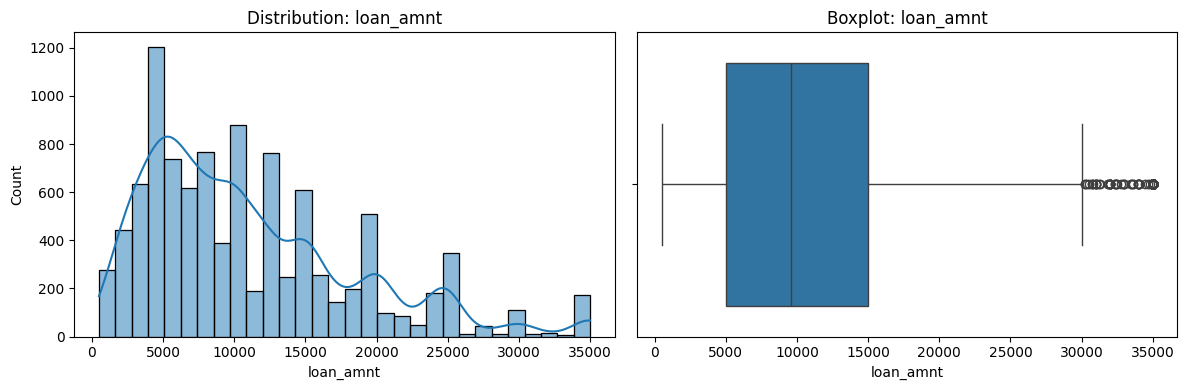

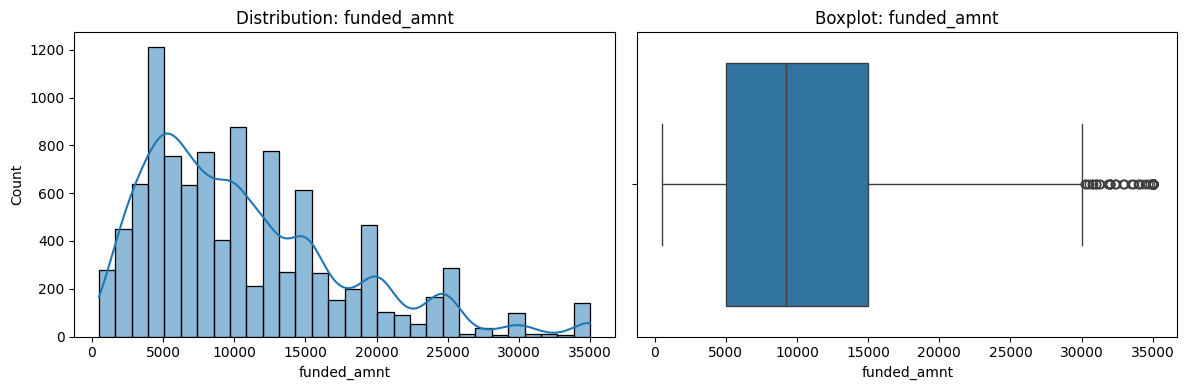

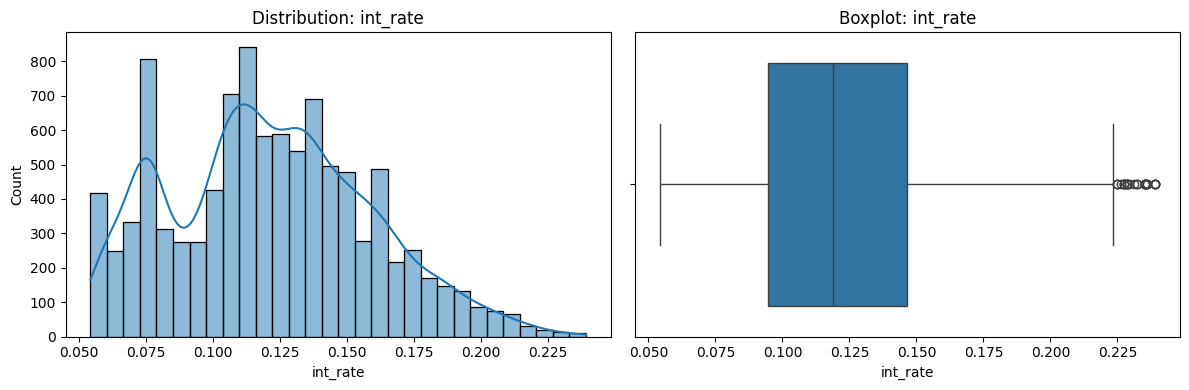

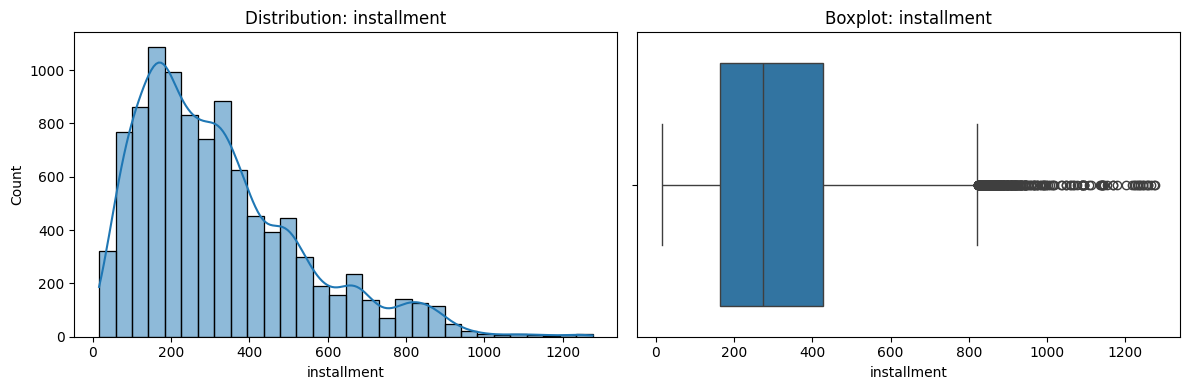

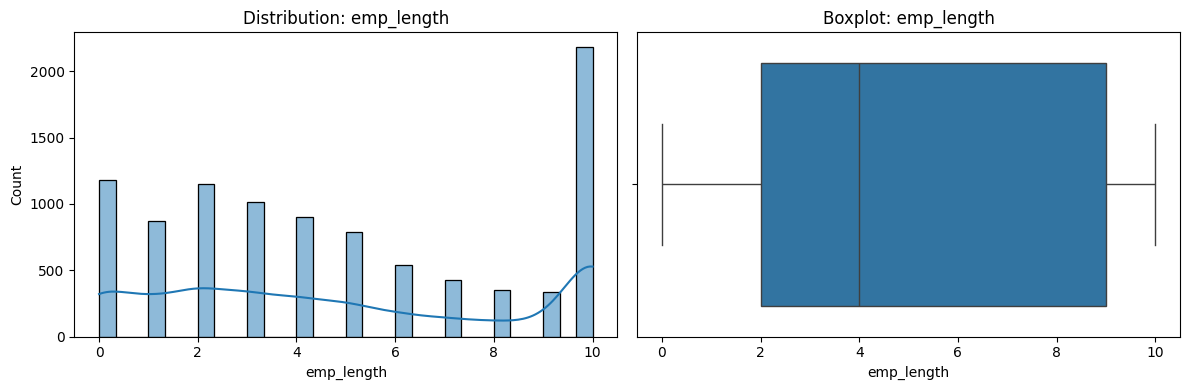

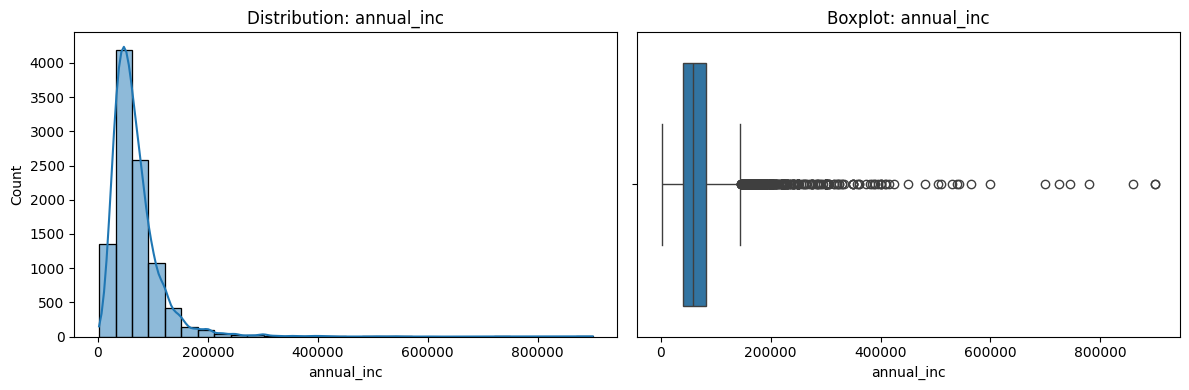

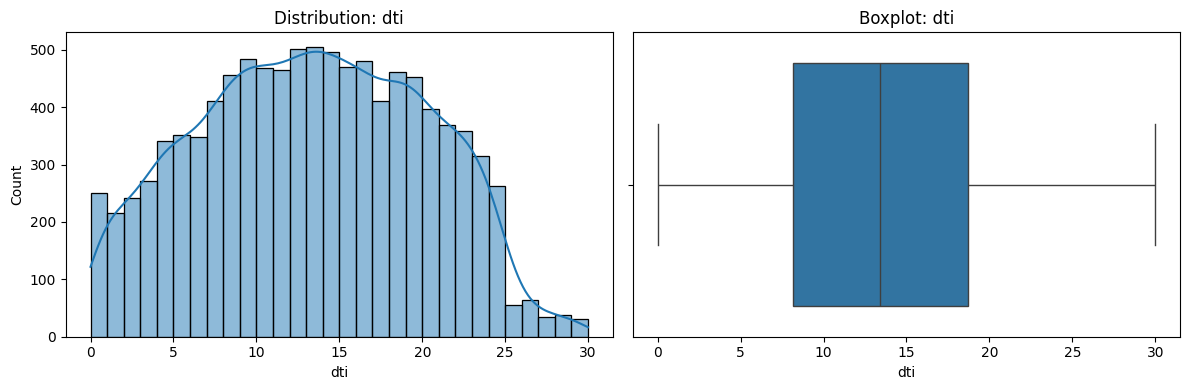

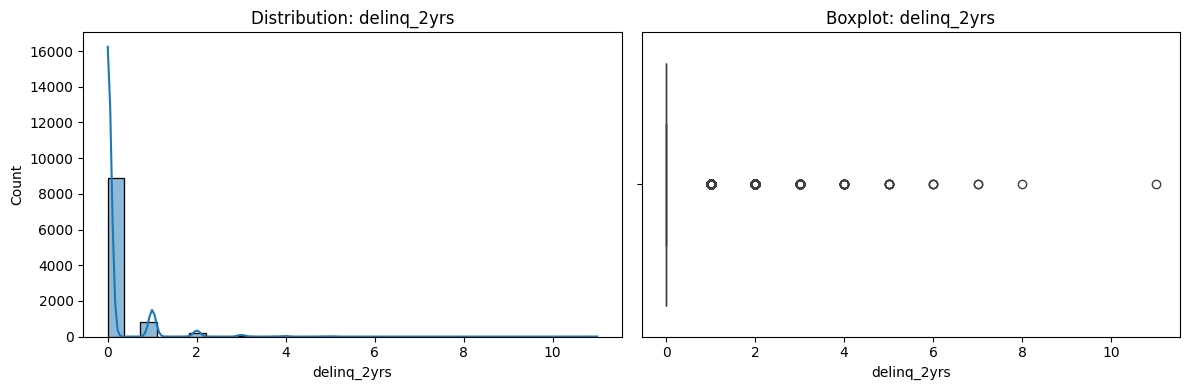

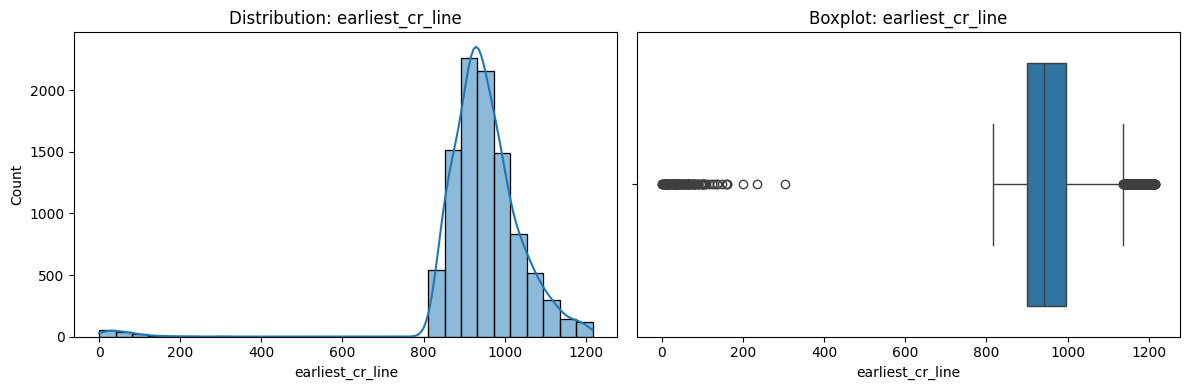

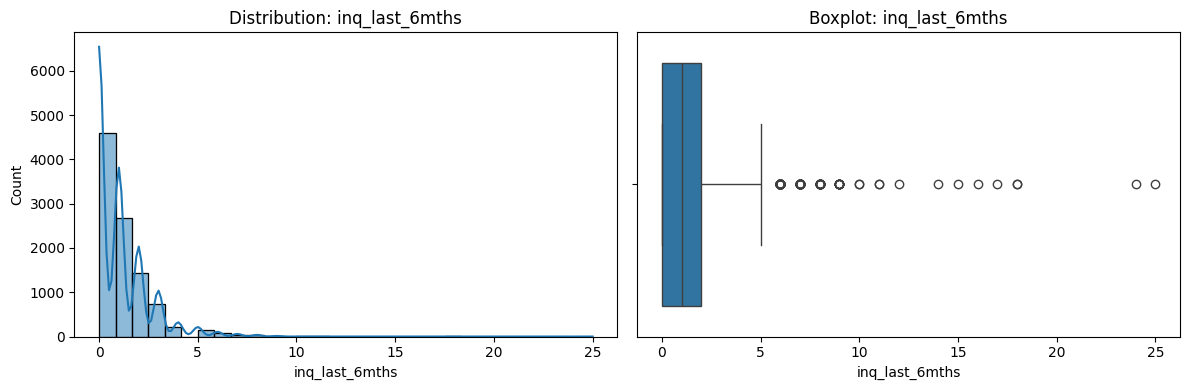

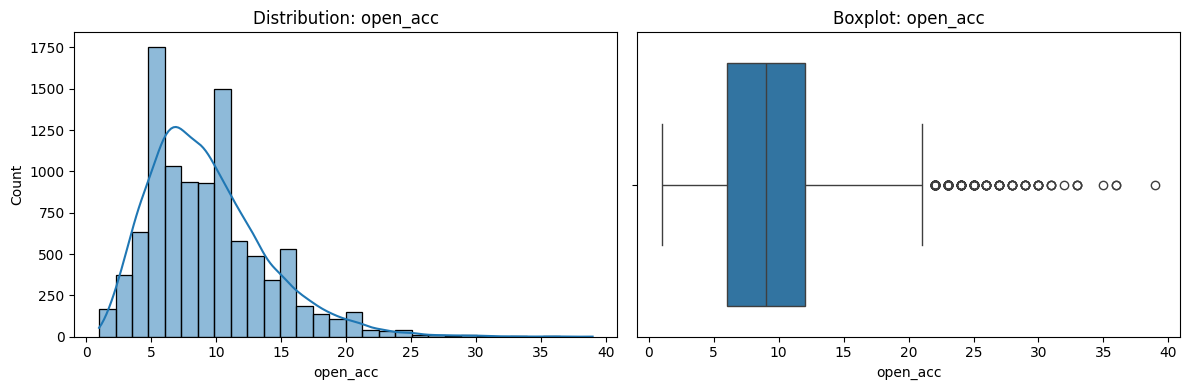

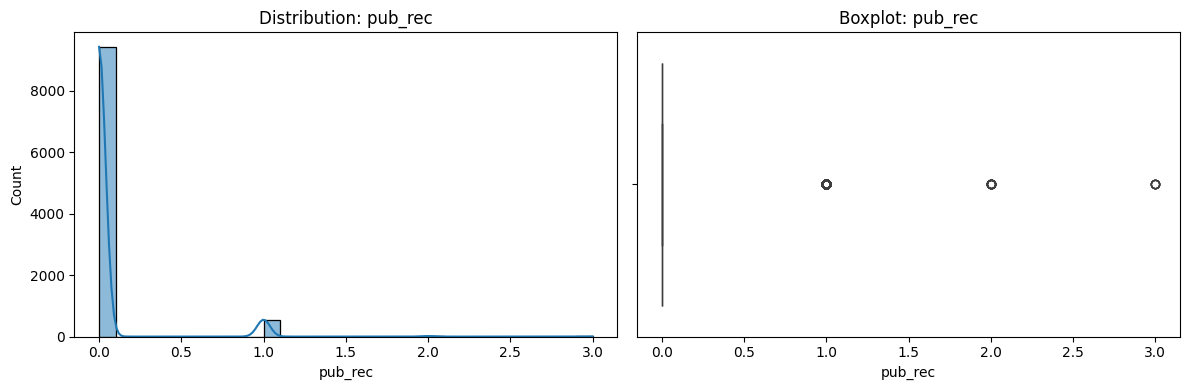

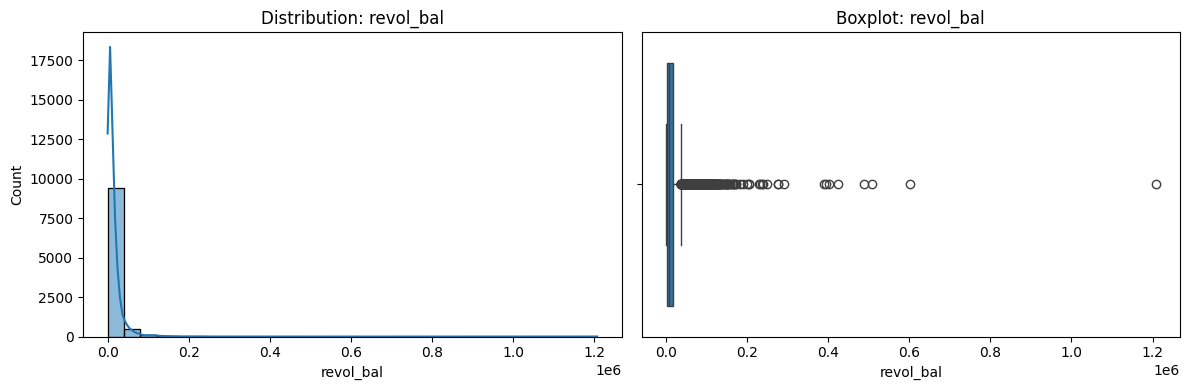

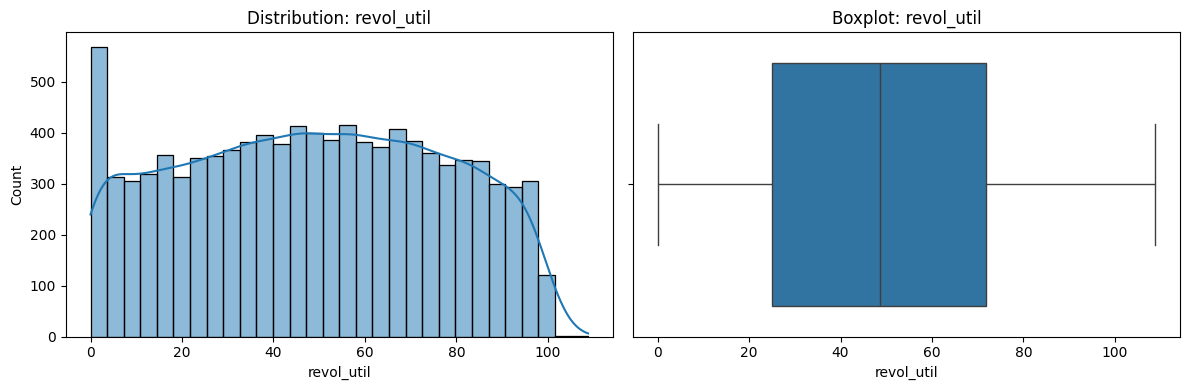

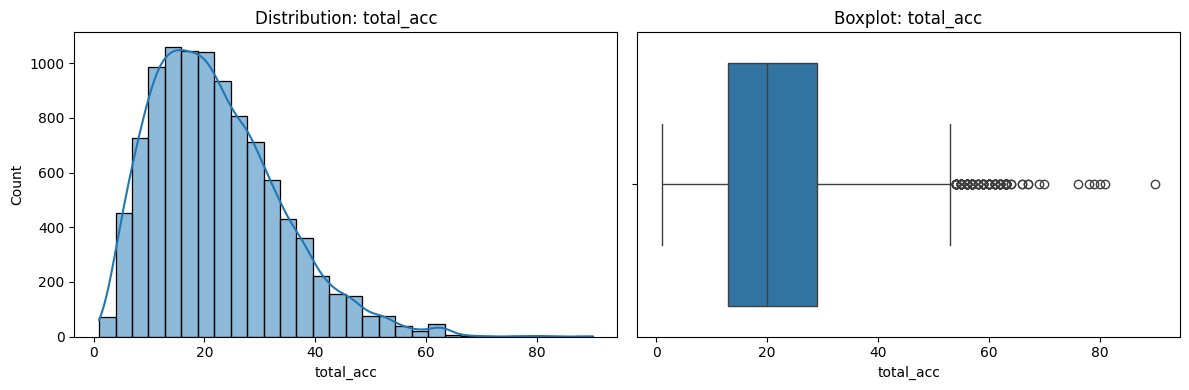

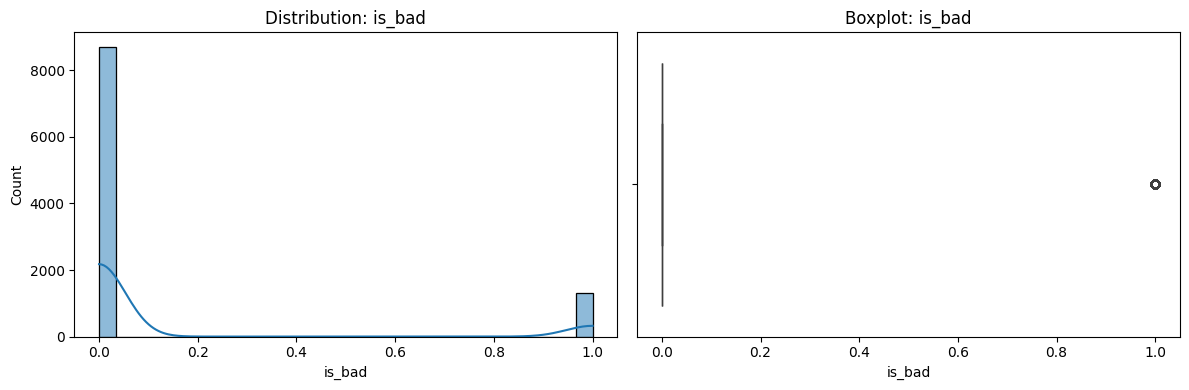

In [18]:
plot_numeric_distribution(data_use)

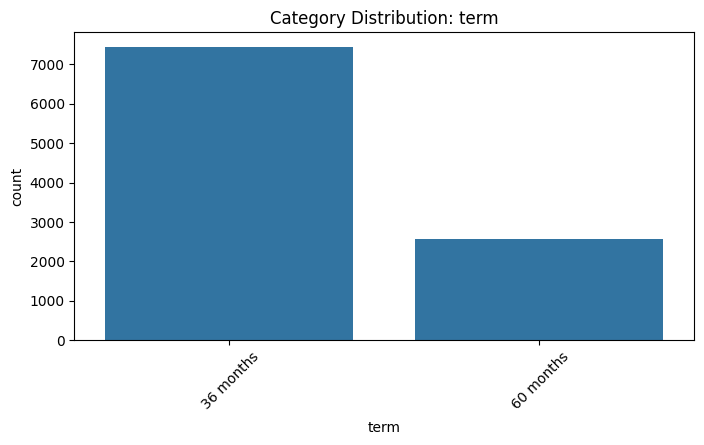

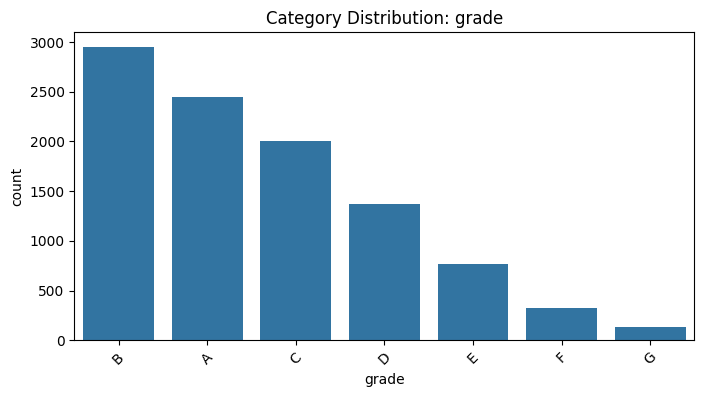

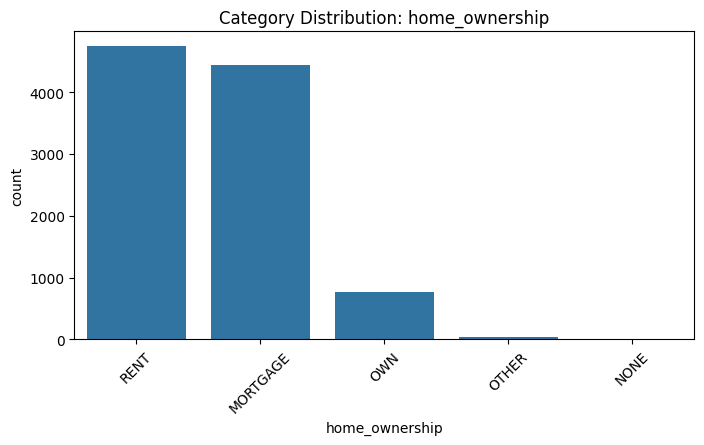

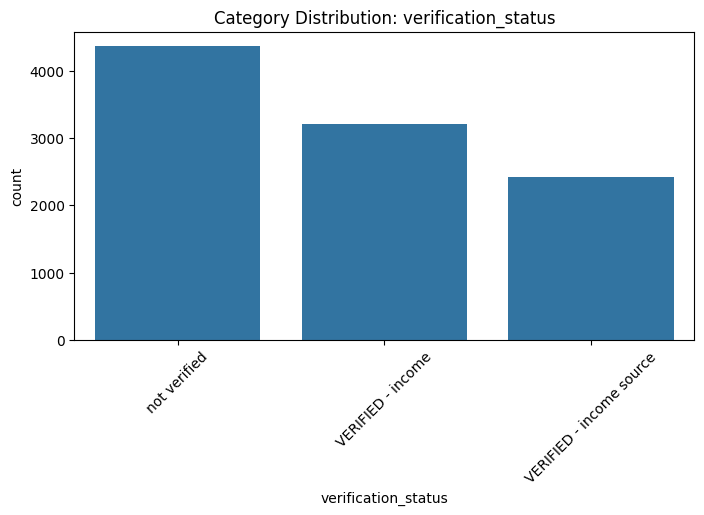

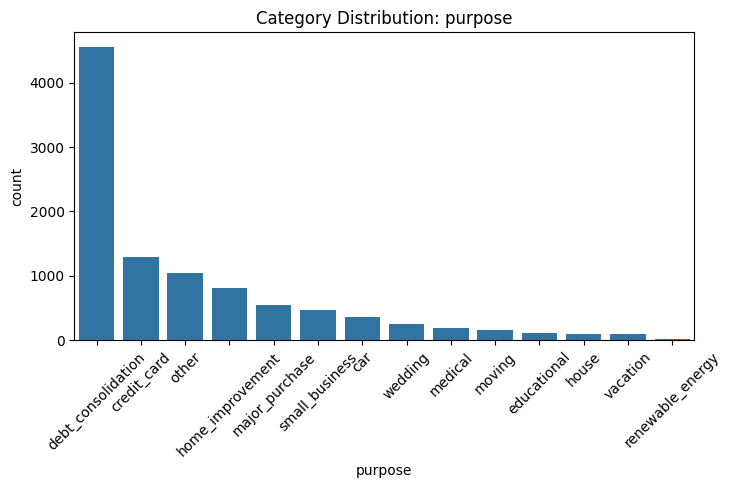

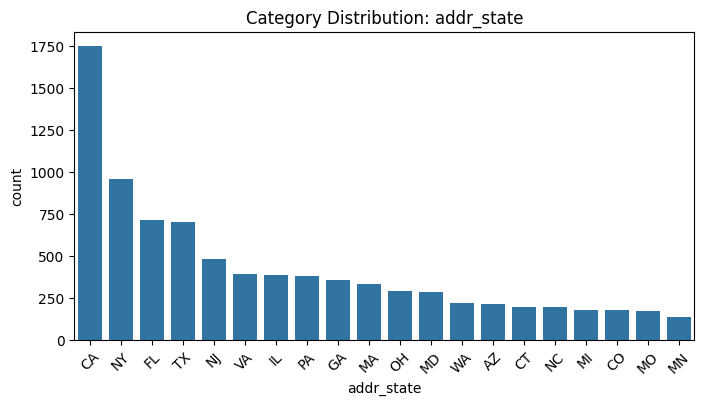

In [19]:
plot_categorical_distribution(data_use)

#### Bivariate (with target)


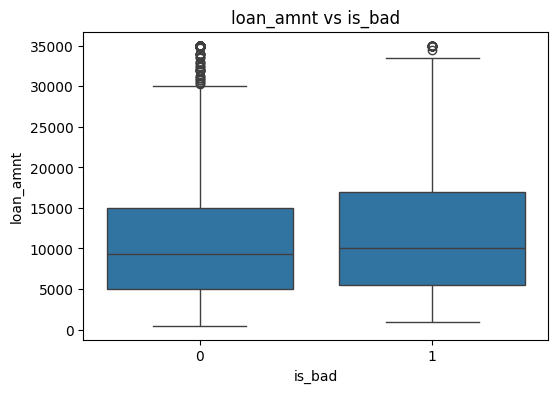

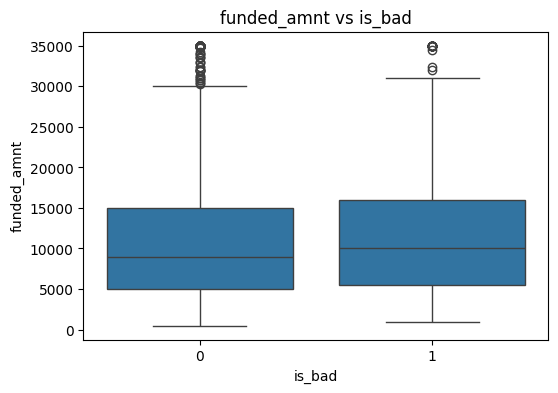

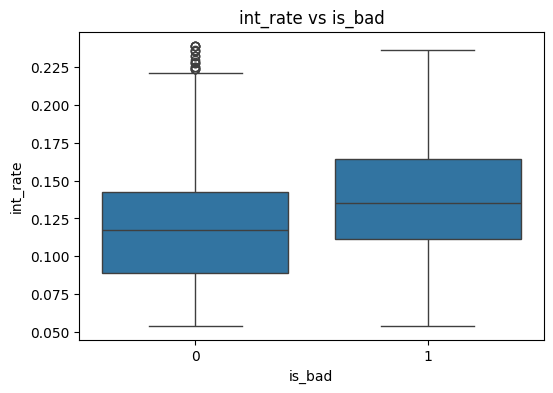

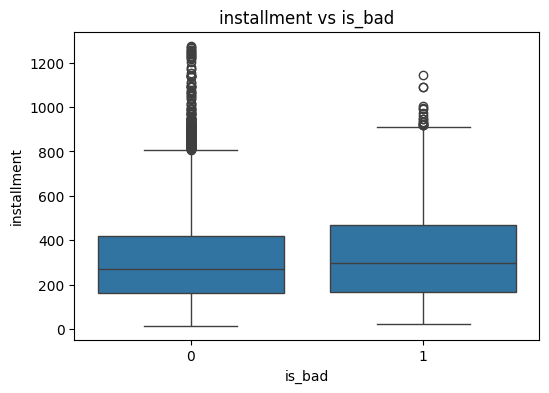

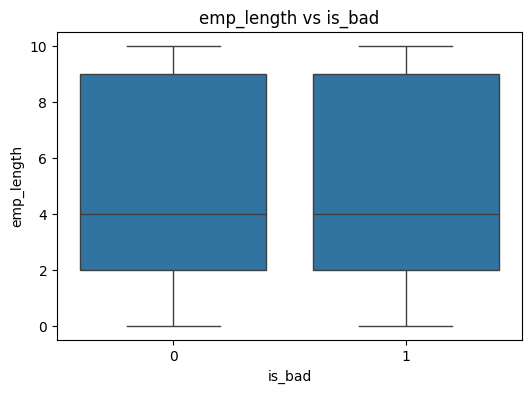

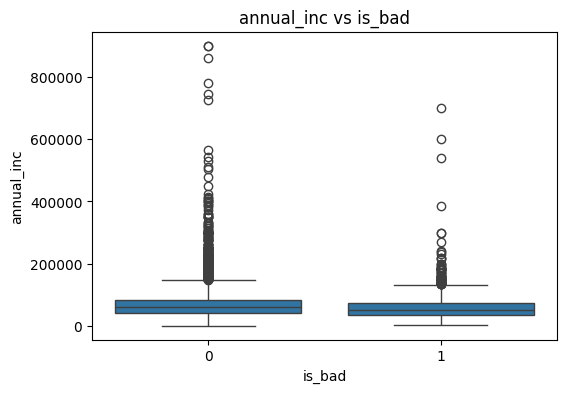

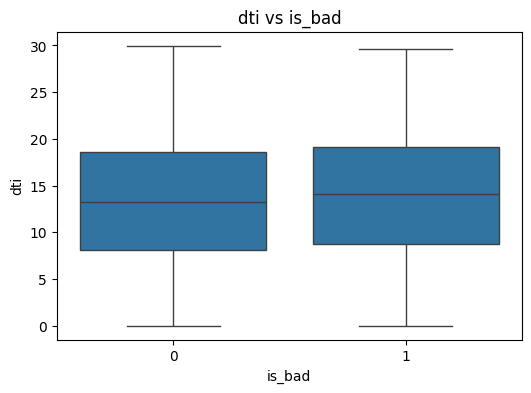

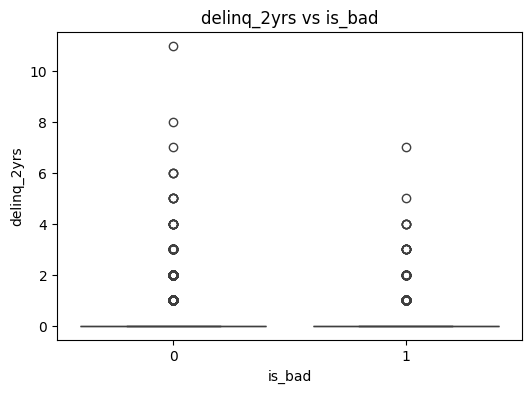

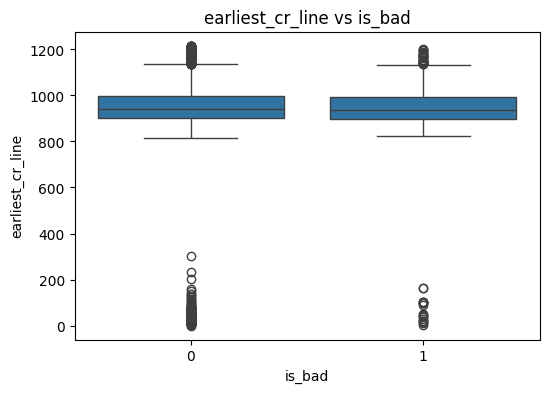

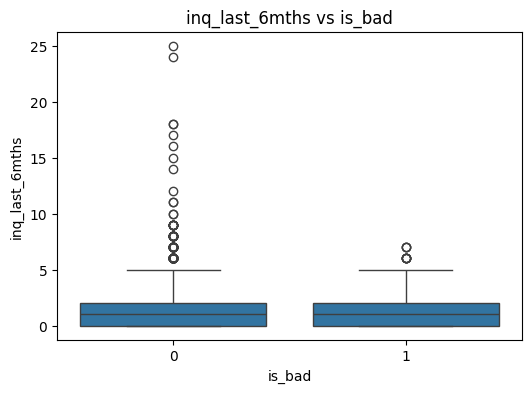

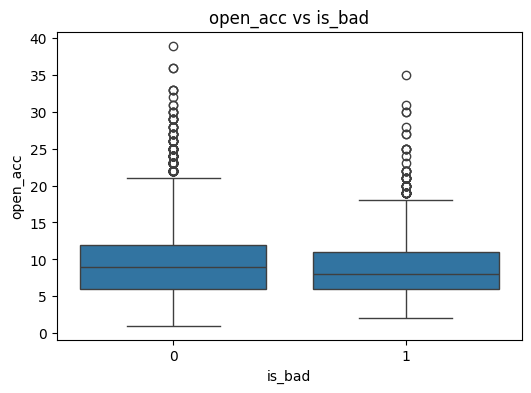

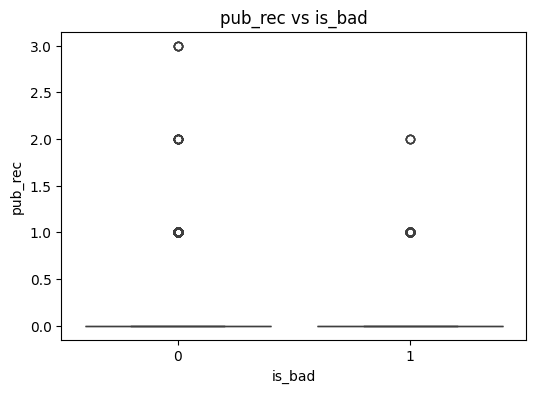

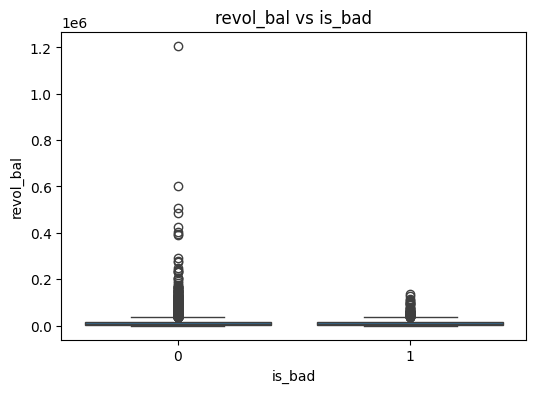

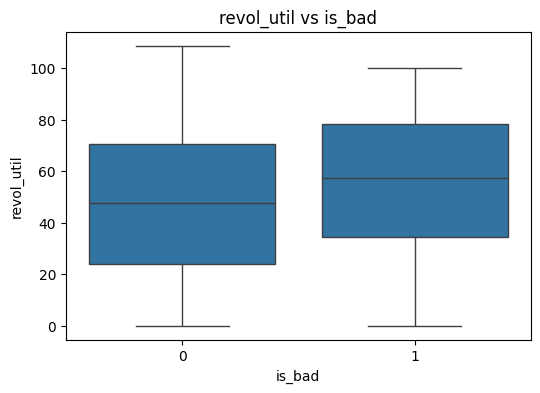

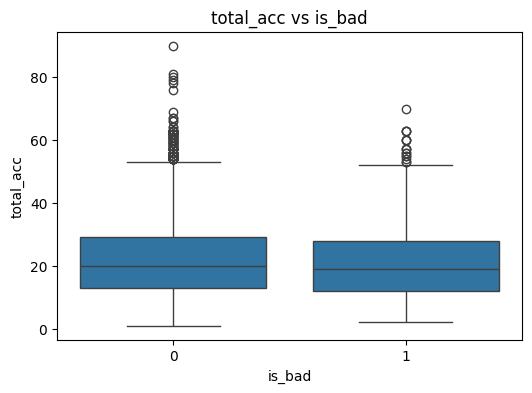

In [20]:
plot_numeric_vs_target_boxplot(data_use, target = 'is_bad')

In [21]:
# plot_numeric_vs_target_hist(data_use, target = 'is_bad')
# plot_numeric_vs_target_boxplot(data_use, target = 'is_bad')

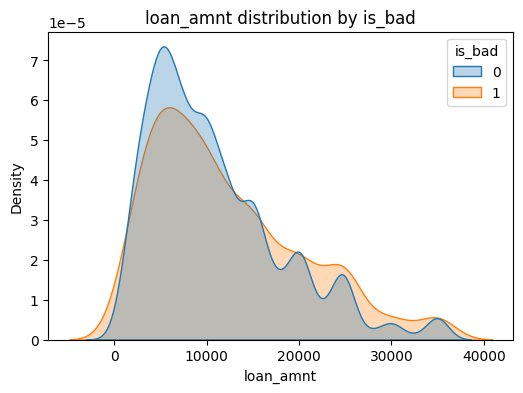

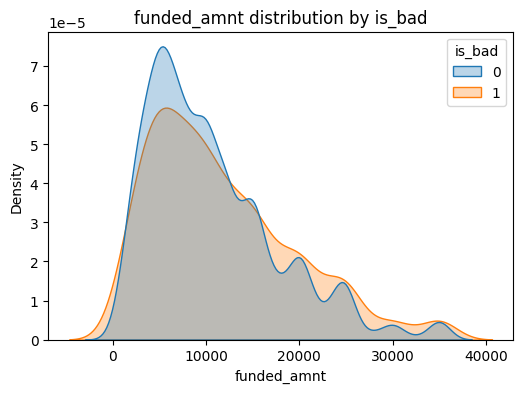

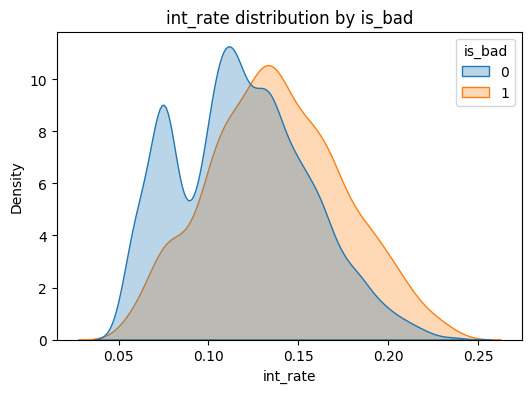

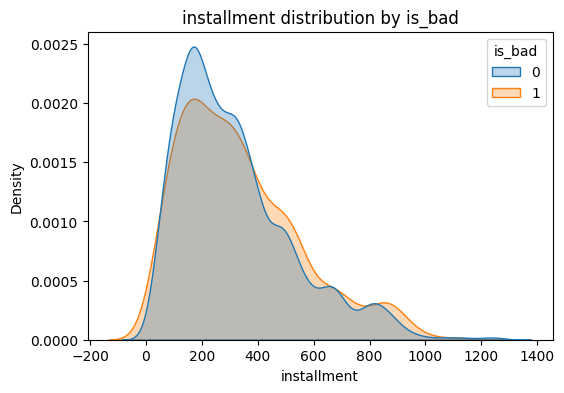

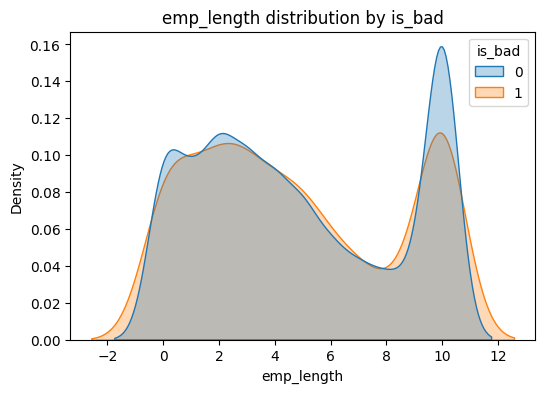

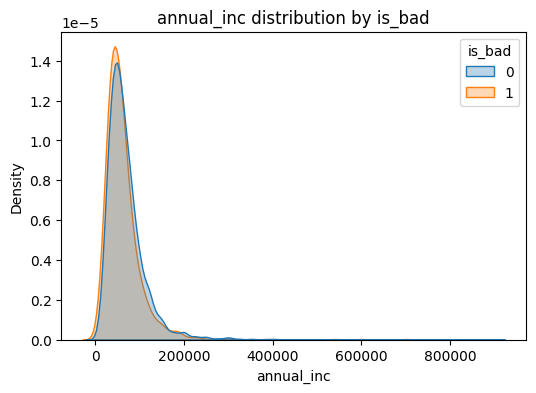

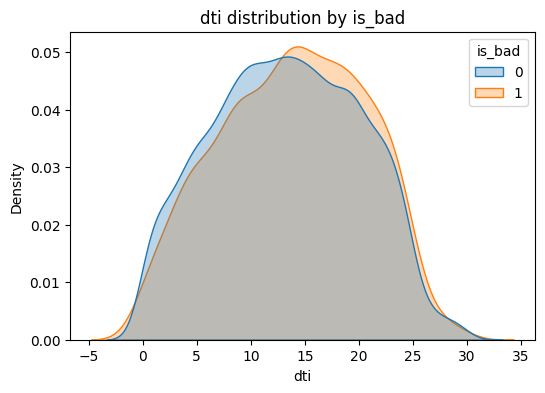

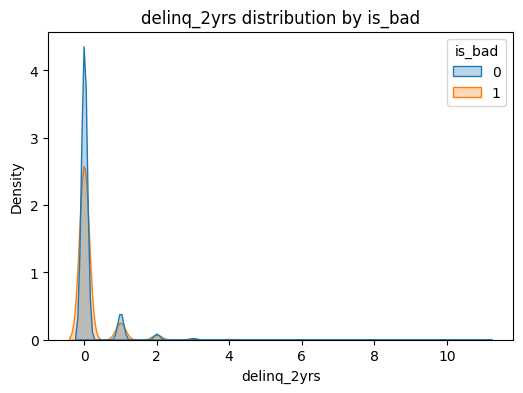

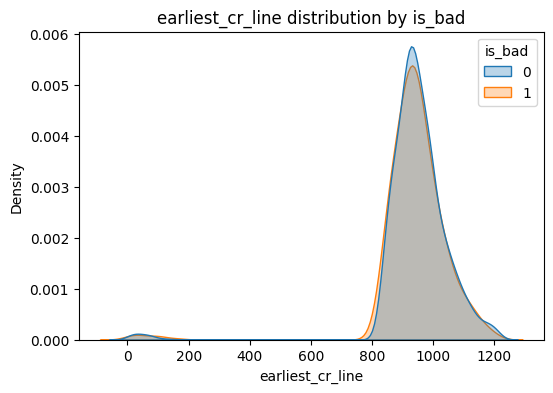

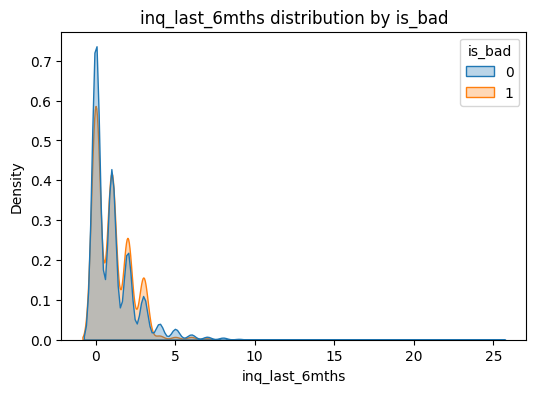

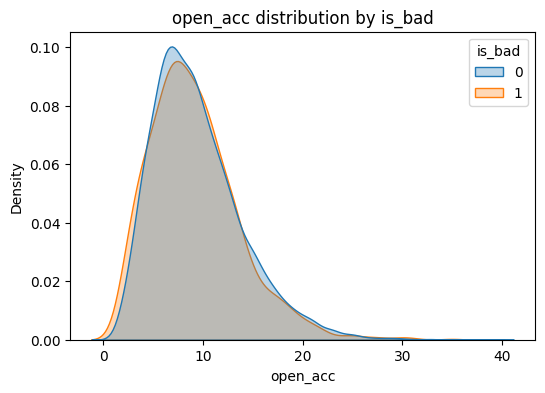

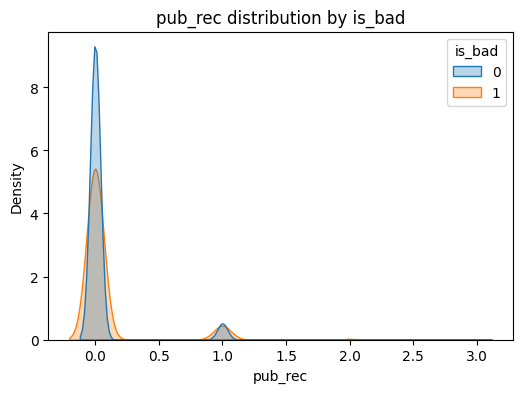

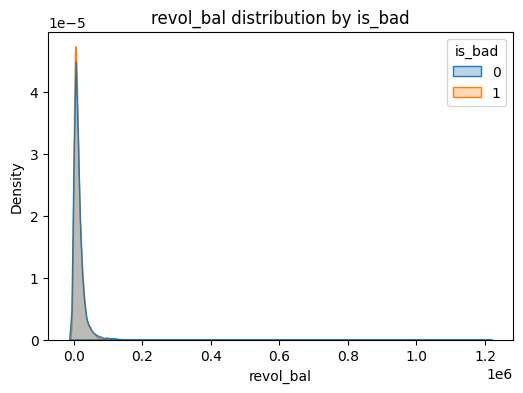

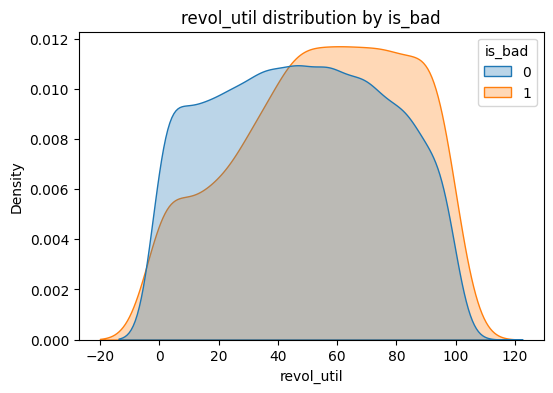

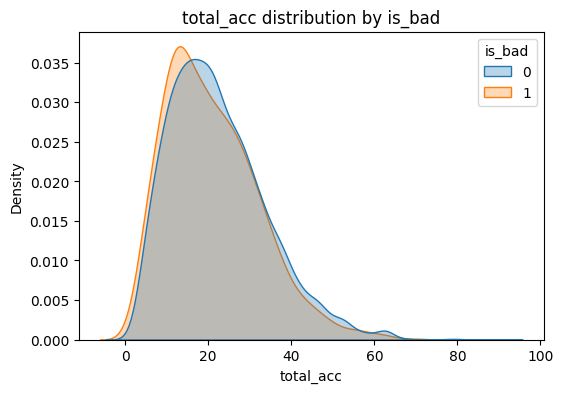

In [22]:
plot_numeric_vs_target_distribution(data_use, target = 'is_bad')

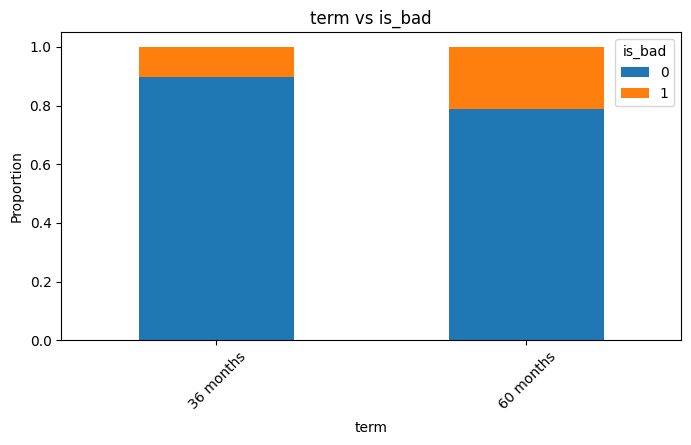

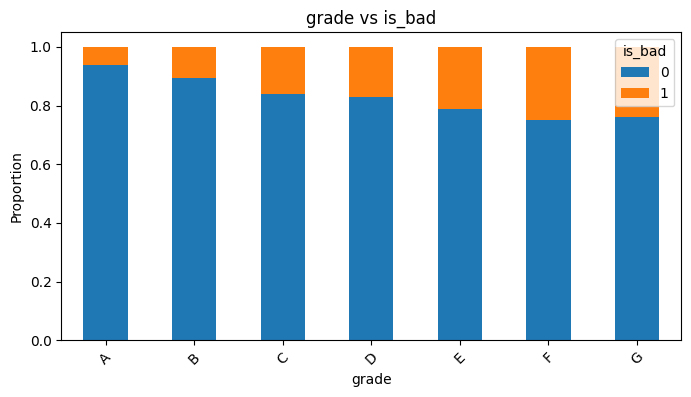

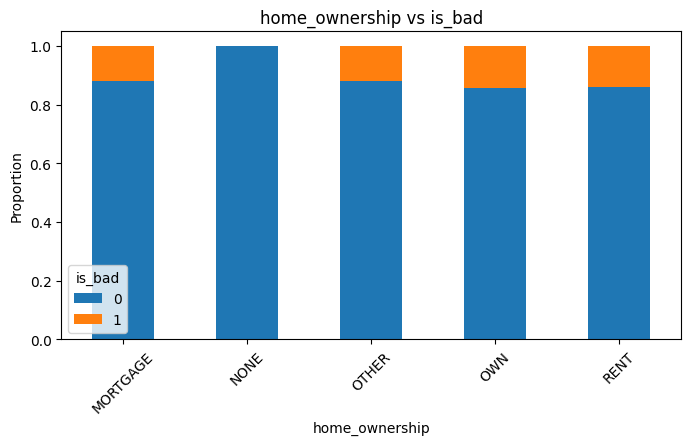

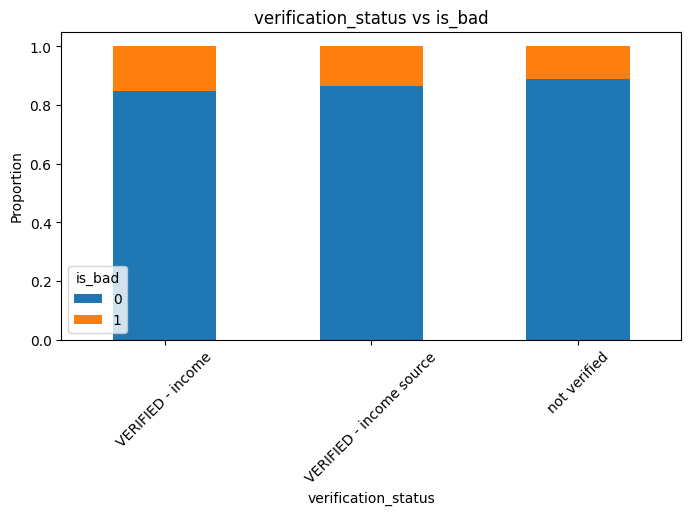

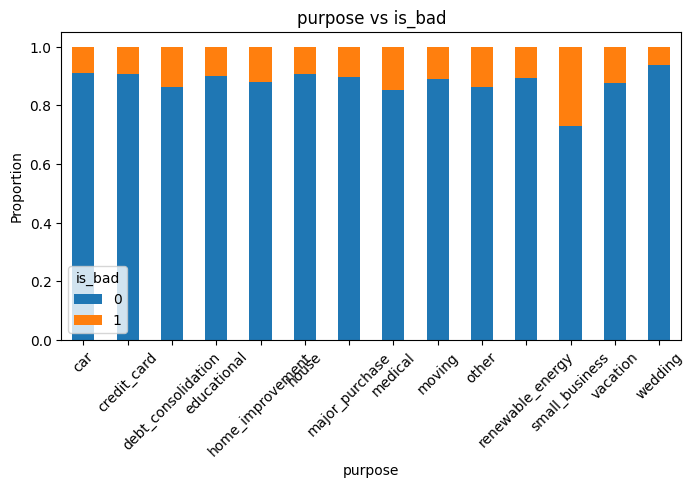

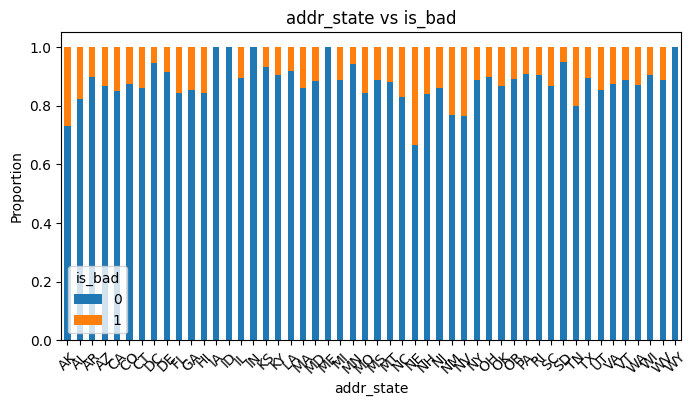

In [23]:
plot_categorical_vs_target(data_use, target = 'is_bad')

#### Correlation analysis


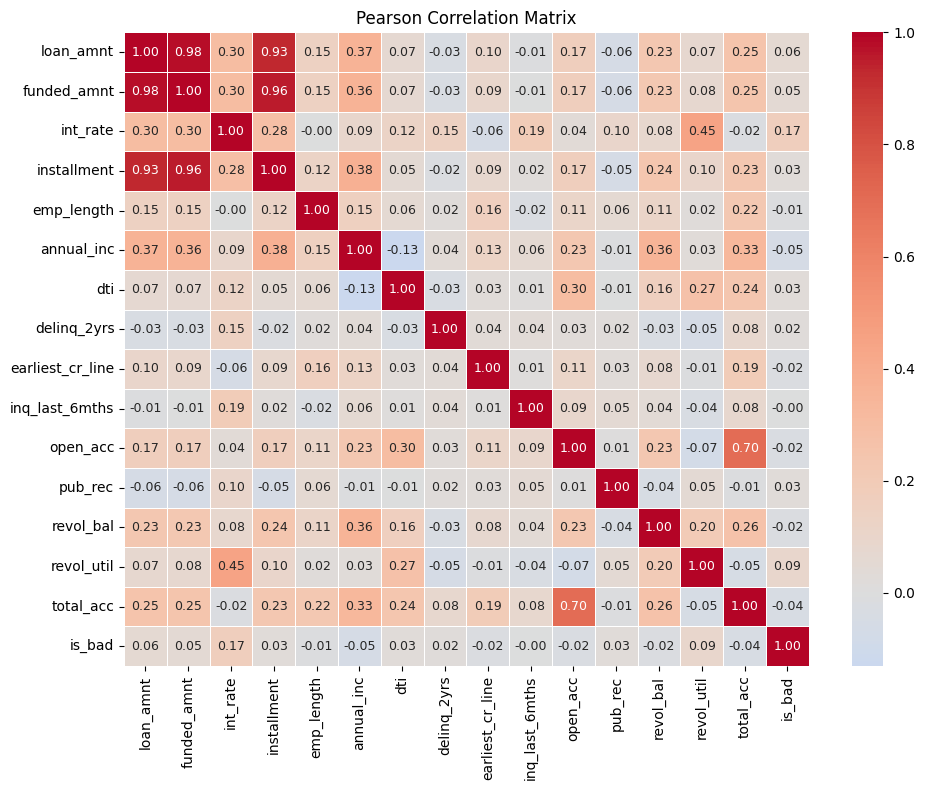

In [24]:
plot_correlation_matrix(data_use)

## Export

In [25]:
data_use.to_csv("../data/interim/10K_Lending_Club_Loans.csv", index=False)